# Residual-suppression ablation — publication plots

This notebook reconstructs the paper figures directly from the saved candidate
and attack outputs. It never hard-codes plotted measurements.

The analysis keeps the target as the unit of variation for ASR, forms margin
deciles separately within every target–surrogate pool, reports every selector
that was run, and treats the experiment as a mechanism study rather than a
proof of the proposition or of the complete bilevel objective.

Set `RESIDUAL_RESULTS_ROOT` when running on another machine. The default points
to the local result directory used for this analysis.

In [1]:
from pathlib import Path
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RESULTS_ROOT = Path(
    os.environ.get(
        "RESIDUAL_RESULTS_ROOT",
        "/Users/mohammad/Downloads/PoisonBase/logs-proposiot",
    )
).expanduser().resolve()
OUTPUT_DIR = RESULTS_ROOT / "figures_publication"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 600
FIG1_SIZE = (14.2, 3.65)
FIG2_SIZE = (14.2, 3.75)

NAVY = "#004481"
BLUE = "#2A78D6"
ORANGE = "#D97732"
SILVER = "#CBD5E1"
MID_GREY = "#7B8794"
DARK = "#18212B"
GRID = "#D9DEE3"
WHITE = "#FFFFFF"

SELECTOR_ORDER = ["full", "no-margin", "high-margin"]
SELECTOR_LABEL = {
    "full": "Full",
    "no-margin": "No margin",
    "high-margin": "High margin",
}
SELECTOR_COLOR = {
    "full": NAVY,
    "no-margin": BLUE,
    "high-margin": ORANGE,
}
ATTACK_LABEL = {"gradmatch": "GM", "sapa": "SAPA"}
ATTACK_COLOR = {"gradmatch": NAVY, "sapa": ORANGE}
ATTACK_MARKER = {"gradmatch": "o", "sapa": "s"}


def set_paper_style():
    sns.set_theme(style="ticks", context="paper")
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "mathtext.fontset": "dejavuserif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.labelweight": "bold",
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "axes.edgecolor": DARK,
        "axes.linewidth": 1.0,
        "xtick.color": DARK,
        "ytick.color": DARK,
        "text.color": DARK,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.facecolor": WHITE,
        "figure.facecolor": WHITE,
    })


def finish_axis(ax, *, log_y=False):
    if log_y:
        ax.grid(True, axis="y", which="major", color=GRID, lw=0.65, ls="--", alpha=0.85)
        ax.grid(True, axis="y", which="minor", color=GRID, lw=0.35, ls=":", alpha=0.45)
    else:
        ax.grid(True, axis="y", color=GRID, lw=0.65, ls="--", alpha=0.85)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="major", length=5, width=1.0)
    ax.tick_params(axis="both", which="minor", length=2.5, width=0.7)
    sns.despine(ax=ax, top=True, right=True)


def save_figure(fig, stem):
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    png = OUTPUT_DIR / f"{stem}.png"
    fig.savefig(pdf, format="pdf", bbox_inches="tight")
    fig.savefig(png, format="png", dpi=DPI, bbox_inches="tight")
    print(f"saved {pdf}")
    print(f"saved {png}")
    return pdf, png


set_paper_style()
print(f"results  {RESULTS_ROOT}")
print(f"figures  {OUTPUT_DIR}")

results  /Users/mohammad/Downloads/PoisonBase/logs-proposiot
figures  /Users/mohammad/Downloads/PoisonBase/logs-proposiot/figures_publication


## Load the saved tables

The notebook uses the processed CSV files for plotting and the raw candidate
caches for independent consistency checks and selected-set relevance.

In [2]:
TABLES = RESULTS_ROOT / "tables"
ABLA = RESULTS_ROOT / "ablation"
CANDIDATES = RESULTS_ROOT / "candidates" / "ConvNetBN" / "dog-bird"

required = {
    "deciles_by_pool": TABLES / "deciles_by_target_model.csv",
    "deciles_pooled": TABLES / "deciles_pooled.csv",
    "selector": TABLES / "selector_ablation.csv",
    "selector_by_target": TABLES / "selector_ablation_by_target.csv",
}
missing = [str(path) for path in required.values() if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing required result files\n" + "\n".join(missing))

deciles_by_pool = pd.read_csv(required["deciles_by_pool"])
deciles_pooled = pd.read_csv(required["deciles_pooled"])
selector_table = pd.read_csv(required["selector"])
selector_by_target = pd.read_csv(required["selector_by_target"])

display(deciles_pooled)
display(selector_table.drop(columns=["run_dir"]))

,margin_decile,candidate_count,residual_norm_median,residual_norm_p90,abs_head_interaction_median,abs_head_interaction_p90,abs_backbone_interaction_median,abs_backbone_interaction_p90
0,1,12500,1.637296e-02,5.981266e-02,8.509272e-01,2.804040e+00,6.533081,29.708632
1,2,12500,4.242143e-03,1.364967e-02,2.281582e-01,6.861533e-01,1.841064,8.010606
2,3,12500,1.451947e-03,5.196914e-03,8.262429e-02,2.618018e-01,0.683487,3.006198
3,4,12500,5.428626e-04,1.919446e-03,3.176094e-02,9.721684e-02,0.263504,1.198144
4,5,12500,1.772498e-04,7.098550e-04,1.095034e-02,3.638756e-02,0.092270,0.424695
5,6,12500,5.432921e-05,2.238906e-04,3.420609e-03,1.185710e-02,0.028000,0.139410
6,7,12500,1.318406e-05,5.470229e-05,8.112076e-04,2.979065e-03,0.006653,0.034180
7,8,12500,1.791591e-06,7.744409e-06,1.038026e-04,4.527969e-04,0.000854,0.005188
8,9,12500,4.578721e-08,5.066887e-07,9.283551e-07,3.024873e-05,0.000000,0.000305
9,10,12500,6.228644e-11,2.455003e-09,6.068672e-12,1.927016e-08,0.000000,0.000000


,attack,selector,targets_with_bases,completed_trials,expected_trials,asr,selected_mean_margin,selected_mean_residual_norm,selected_mean_abs_head_interaction,selected_mean_abs_backbone_interaction
0,gradmatch,full,5,25,25,0.32,5.347587,0.029533,1.622780,18.194672
1,gradmatch,no-margin,5,25,25,0.36,5.721026,0.026810,1.520791,17.219590
2,gradmatch,high-margin,5,25,25,0.00,17.110130,0.000198,0.015179,0.147402
3,sapa,full,5,25,25,0.28,5.347587,0.029533,1.622780,18.194672
4,sapa,no-margin,5,25,25,0.36,5.721026,0.026810,1.520791,17.219590
5,sapa,high-margin,5,25,25,0.00,17.110130,0.000198,0.015179,0.147402


## Reviewer-facing audit

These checks prevent accidental pooling across incomparable groups, incomplete
victim grids, cherry-picked deciles, and inconsistent selector caches. They
fail loudly if the saved experiment no longer matches the reported design.

In [3]:
POOL_KEYS = ["target_idx", "model_id"]
METRICS = [
    "residual_norm",
    "abs_head_interaction",
    "abs_backbone_interaction",
]
STAT_COLUMNS = [f"{metric}_{stat}" for metric in METRICS for stat in ("median", "p90")]

assert len(deciles_by_pool) == 25 * 10
assert deciles_by_pool.groupby(POOL_KEYS).ngroups == 25
assert set(deciles_by_pool.groupby(POOL_KEYS).size()) == {10}
assert set(deciles_by_pool["margin_decile"]) == set(range(1, 11))
assert set(deciles_by_pool["candidate_count"]) == {500}
assert len(deciles_pooled) == 10
assert set(deciles_pooled["candidate_count"]) == {12_500}

monotonic_rows = []
for key, frame in deciles_by_pool.groupby(POOL_KEYS, sort=True):
    frame = frame.sort_values("margin_decile")
    row = {"target_idx": int(key[0]), "model_id": int(key[1])}
    for column in STAT_COLUMNS:
        values = frame[column].to_numpy(float)
        row[column] = bool(np.all(np.diff(values) <= 0.0))
    monotonic_rows.append(row)
monotonic_audit = pd.DataFrame(monotonic_rows)
assert monotonic_audit[STAT_COLUMNS].to_numpy().all()

assert set(selector_table["selector"]) == set(SELECTOR_ORDER)
assert set(selector_table["attack"]) == {"gradmatch", "sapa"}
assert len(selector_table) == 6
assert (selector_table["completed_trials"] == 25).all()
assert (selector_table["expected_trials"] == 25).all()
assert len(selector_by_target) == 2 * 3 * 5
assert (selector_by_target["completed_victims"] == 5).all()
assert (selector_by_target["expected_victims"] == 5).all()
target_sets = selector_by_target.groupby(["attack", "selector"])["target_idx"].apply(set)
assert len({tuple(sorted(x)) for x in target_sets}) == 1

candidate_files = sorted(CANDIDATES.glob("target_*.npz"))
assert len(candidate_files) == 5
checked = 0
violations = 0
for path in candidate_files:
    with np.load(path, allow_pickle=False) as data:
        assert int(data["candidate_count"]) == 5_000
        assert int(data["model_count"]) == 5
        margin = data["margin"].astype(np.float64)
        residual = data["residual_norm"].astype(np.float64)
        upper = np.sqrt(2.0) * 9.0 / (np.exp(np.clip(margin, -700, 700)) + 9.0)
        violations += int(np.sum(residual > upper * (1.0 + 1e-4) + 1e-8))
        checked += len(margin)
assert checked == 125_000
assert violations == 0

# Use deciles 1 and 9 so the reduction does not rely on numerical zeros in D10.
d1 = deciles_pooled.set_index("margin_decile").loc[1]
d9 = deciles_pooled.set_index("margin_decile").loc[9]
p90_reduction = {
    metric: float(d1[f"{metric}_p90"] / d9[f"{metric}_p90"])
    for metric in METRICS
}

audit_summary = pd.DataFrame({
    "check": [
        "Target–surrogate pools",
        "Candidate–surrogate evaluations",
        "Monotone median and P90 trajectories",
        "Pointwise residual-bound violations",
        "Completed victim trials per attack and selector",
    ],
    "result": [
        "25",
        f"{checked:,}",
        f"{int(monotonic_audit[STAT_COLUMNS].all(axis=1).sum())}/25 pools",
        str(violations),
        "25/25",
    ],
})
display(audit_summary)
print("P90 reduction from margin decile 1 to 9")
for metric, value in p90_reduction.items():
    print(f"  {metric:32s} {value:,.0f}x")

,check,result
0,Target–surrogate pools,25
1,Candidate–surrogate evaluations,"125,000"
2,Monotone median and P90 trajectories,25/25 pools
3,Pointwise residual-bound violations,0
4,Completed victim trials per attack and selector,25/25


P90 reduction from margin decile 1 to 9
  residual_norm                    118,046x
  abs_head_interaction             92,699x
  abs_backbone_interaction         97,349x


## Figure 1 — residual suppression across margin deciles

Thin silver trajectories show the median in every target–surrogate pool.
Thick curves show the pooled median and pooled 90th percentile. The logarithmic
axes expose the full five-order trend. Downward triangles denote numerical
zeros placed at the plotting floor rather than silently removed.

saved /Users/mohammad/Downloads/PoisonBase/logs-proposiot/figures_publication/residual_suppression_deciles.pdf
saved /Users/mohammad/Downloads/PoisonBase/logs-proposiot/figures_publication/residual_suppression_deciles.png


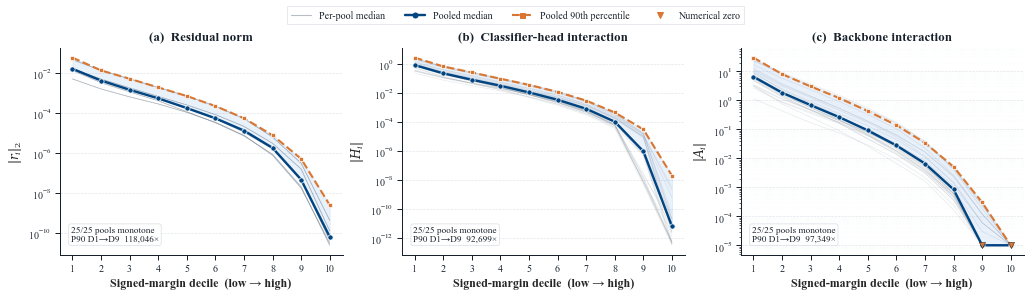

In [4]:
plot_specs = [
    ("residual_norm", r"$\|r_i\|_2$", "Residual norm"),
    ("abs_head_interaction", r"$|H_i|$", "Classifier-head interaction"),
    ("abs_backbone_interaction", r"$|A_i|$", "Backbone interaction"),
]

fig, axes = plt.subplots(1, 3, figsize=FIG1_SIZE, constrained_layout=True)
x = deciles_pooled["margin_decile"].to_numpy()

for panel, (ax, (metric, ylabel, title)) in enumerate(zip(axes, plot_specs)):
    med_col = f"{metric}_median"
    p90_col = f"{metric}_p90"
    all_positive = np.concatenate([
        deciles_by_pool.loc[deciles_by_pool[med_col] > 0, med_col].to_numpy(float),
        deciles_pooled.loc[deciles_pooled[med_col] > 0, med_col].to_numpy(float),
        deciles_pooled.loc[deciles_pooled[p90_col] > 0, p90_col].to_numpy(float),
    ])
    floor = float(all_positive.min() / 3.0)

    for _, frame in deciles_by_pool.groupby(POOL_KEYS, sort=True):
        frame = frame.sort_values("margin_decile")
        values = frame[med_col].to_numpy(float)
        ax.plot(
            frame["margin_decile"].to_numpy(float), np.maximum(values, floor),
            color=MID_GREY, lw=0.65, alpha=0.18, zorder=1,
        )

    median_raw = deciles_pooled[med_col].to_numpy(float)
    p90_raw = deciles_pooled[p90_col].to_numpy(float)
    median = np.maximum(median_raw, floor)
    p90 = np.maximum(p90_raw, floor)
    ax.fill_between(x, median, p90, color=BLUE, alpha=0.10, zorder=2)
    ax.plot(
        x, median, color=NAVY, lw=2.4, marker="o", ms=5.2,
        markeredgecolor=WHITE, markeredgewidth=0.7, zorder=4,
    )
    ax.plot(
        x, p90, color=ORANGE, lw=2.1, ls="--", marker="s", ms=4.8,
        markeredgecolor=WHITE, markeredgewidth=0.7, zorder=4,
    )

    zero_x = np.unique(np.concatenate([x[median_raw == 0], x[p90_raw == 0]]))
    if len(zero_x):
        ax.scatter(
            zero_x, np.full(len(zero_x), floor), marker="v", s=38,
            facecolor=ORANGE, edgecolor=DARK, linewidth=0.5, zorder=6,
        )

    ax.text(
        0.04, 0.055,
        f"25/25 pools monotone\nP90 D1→D9  {p90_reduction[metric]:,.0f}×",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=9.2,
        bbox=dict(boxstyle="round,pad=0.24", facecolor=WHITE, edgecolor=GRID, linewidth=0.7),
    )
    ax.set_title(f"({chr(97 + panel)})  {title}", pad=8)
    ax.set_xlabel("Signed-margin decile  (low → high)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 11))
    ax.set_yscale("log")
    finish_axis(ax, log_y=True)

legend_handles = [
    Line2D([0], [0], color=MID_GREY, lw=1.1, alpha=0.55, label="Per-pool median"),
    Line2D([0], [0], color=NAVY, lw=2.4, marker="o", ms=5, label="Pooled median"),
    Line2D([0], [0], color=ORANGE, lw=2.1, ls="--", marker="s", ms=5,
           label="Pooled 90th percentile"),
    Line2D([0], [0], color=ORANGE, marker="v", lw=0, ms=6, label="Numerical zero"),
]
fig.legend(
    handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.105),
    ncol=4, frameon=True, fancybox=False, edgecolor=GRID,
)
save_figure(fig, "residual_suppression_deciles")
plt.show()

**Suggested caption**

*Residual suppression across signed-margin deciles. Deciles are formed
separately within each of 25 target–surrogate pools and pooled only afterward.
Thin curves show the per-pool medians, while thick curves show pooled medians
and 90th percentiles over 12,500 candidate–surrogate evaluations per decile.
All six median and 90th-percentile trajectories decrease monotonically in
every pool. From the first to ninth decile, the 90th percentiles of the
residual norm, classifier-head interaction, and backbone interaction decrease
by approximately $1.18\times10^5$, $9.27\times10^4$, and $9.74\times10^4$.
Downward markers denote numerical zeros at the evaluation precision.*

## Reconstruct and audit the controlled selector intervention

Selection statistics are recomputed from the raw candidate caches and
selected-index JSON files. The notebook verifies that GM and SAPA use
identical base sets for each selector and that the CSV summaries match the raw
values.

In [5]:
def discover_runs(root):
    mapping = {}
    if not root.is_dir():
        raise FileNotFoundError(root)
    for run_dir in root.iterdir():
        if not run_dir.is_dir():
            continue
        name = run_dir.name
        attack = "gradmatch" if "_gradmatch_" in name else ("sapa" if "_sapa_" in name else None)
        if "_selresfull" in name:
            selector = "full"
        elif "_selresnomargin" in name:
            selector = "no-margin"
        elif "_selreshighmargin" in name:
            selector = "high-margin"
        else:
            selector = None
        if attack and selector:
            key = (attack, selector)
            if key in mapping:
                raise RuntimeError(f"Duplicate run for {key}")
            mapping[key] = run_dir
    expected = {(attack, selector) for attack in ATTACK_LABEL for selector in SELECTOR_ORDER}
    if set(mapping) != expected:
        raise RuntimeError(f"Run discovery mismatch\nmissing={expected-set(mapping)}\nextra={set(mapping)-expected}")
    return mapping


def load_base_sets(run_dir):
    result = {}
    for path in sorted((run_dir / "poison_cache").glob("base_*.json")):
        target = int(path.stem.split("_", 1)[1])
        result[target] = set(json.loads(path.read_text()))
    if len(result) != 5 or any(len(indices) != 100 for indices in result.values()):
        raise RuntimeError(f"Incomplete selected-index cache in {run_dir}")
    return result


runs = discover_runs(ABLA)
base_sets = {key: load_base_sets(path) for key, path in runs.items()}
for selector in SELECTOR_ORDER:
    assert base_sets[("gradmatch", selector)] == base_sets[("sapa", selector)]

candidate_cache = {}
for path in candidate_files:
    with np.load(path, allow_pickle=False) as data:
        target = int(data["target_idx"])
        candidate_cache[target] = {key: data[key].copy() for key in data.files}
assert set(candidate_cache) == set(next(iter(base_sets.values())))

recomputed_rows = []
for selector in SELECTOR_ORDER:
    values = {name: [] for name in (
        "margin", "residual_norm", "head_interaction", "backbone_interaction", "relevance"
    )}
    selected_by_target = base_sets[("gradmatch", selector)]
    for target, selected in selected_by_target.items():
        data = candidate_cache[target]
        mask = np.isin(data["candidate_idx"], np.fromiter(selected, dtype=np.int64))
        assert int(mask.sum()) == 100 * int(data["model_count"])
        for name in values:
            values[name].append(np.asarray(data[name][mask], dtype=np.float64))
    merged = {name: np.concatenate(parts) for name, parts in values.items()}
    recomputed_rows.append({
        "selector": selector,
        "selected_mean_margin": merged["margin"].mean(),
        "selected_mean_relevance": merged["relevance"].mean(),
        "selected_mean_residual_norm": merged["residual_norm"].mean(),
        "selected_mean_abs_head_interaction": np.abs(merged["head_interaction"]).mean(),
        "selected_mean_abs_backbone_interaction": np.abs(merged["backbone_interaction"]).mean(),
    })

recomputed = pd.DataFrame(recomputed_rows).set_index("selector").loc[SELECTOR_ORDER]
source_metrics = [
    "selected_mean_margin",
    "selected_mean_residual_norm",
    "selected_mean_abs_head_interaction",
    "selected_mean_abs_backbone_interaction",
]
for selector, frame in selector_table.groupby("selector"):
    for column in source_metrics:
        assert np.allclose(frame[column], frame[column].iloc[0], rtol=0, atol=1e-10)
        assert np.isclose(
            recomputed.loc[selector, column], frame[column].iloc[0], rtol=1e-6, atol=1e-8
        )

summary = recomputed.copy()
for attack in ATTACK_LABEL:
    attack_rows = selector_table[selector_table["attack"] == attack].set_index("selector")
    summary[f"{attack}_asr"] = attack_rows.loc[SELECTOR_ORDER, "asr"].to_numpy(float)
    cta = {}
    for selector in SELECTOR_ORDER:
        payload = json.loads((runs[(attack, selector)] / "summary.json").read_text())
        assert int(payload["num_trials"]) == 25
        cta[selector] = float(payload["cta_post_mean"])
    summary[f"{attack}_cta"] = pd.Series(cta)

overlap_rows = []
for left, right in [("full", "no-margin"), ("full", "high-margin"), ("no-margin", "high-margin")]:
    overlaps = [
        len(base_sets[("gradmatch", left)][target] & base_sets[("gradmatch", right)][target])
        for target in sorted(candidate_cache)
    ]
    overlap_rows.append({
        "comparison": f"{SELECTOR_LABEL[left]} vs {SELECTOR_LABEL[right]}",
        "mean_overlap_of_100": np.mean(overlaps),
        "per_target": overlaps,
    })
overlap_audit = pd.DataFrame(overlap_rows)
assert np.isclose(
    overlap_audit.loc[
        overlap_audit["comparison"] == "Full vs No margin", "mean_overlap_of_100"
    ].iloc[0],
    91.6,
)

display(summary)
display(overlap_audit)

,selected_mean_margin,selected_mean_relevance,selected_mean_residual_norm,selected_mean_abs_head_interaction,selected_mean_abs_backbone_interaction,gradmatch_asr,gradmatch_cta,sapa_asr,sapa_cta
selector,,,,,,,,,
full,5.347587,0.304226,0.029533,1.622780,18.194671,0.32,0.805864,0.28,0.805208
no-margin,5.721026,0.312487,0.026810,1.520791,17.219590,0.36,0.804320,0.36,0.804876
high-margin,17.110130,0.310641,0.000198,0.015179,0.147402,0.00,0.804968,0.00,0.803788


,comparison,mean_overlap_of_100,per_target
0,Full vs No margin,91.6,"[90, 88, 92, 95, 93]"
1,Full vs High margin,0.2,"[0, 1, 0, 0, 0]"
2,No margin vs High margin,0.6,"[0, 2, 0, 0, 1]"


## Figure 2 — controlled intervention and attack outcome

Panel (a) establishes that the high-margin control does not lose
representation relevance. Panel (b) shows the alignment magnitudes relative
to Full selection on a logarithmic scale. Panel (c) displays target-level ASR
for all five paired targets and both poison optimizers. No victim-level
confidence interval is used because retrainings sharing a target and poison
set are not independent experimental units.

saved /Users/mohammad/Downloads/PoisonBase/logs-proposiot/figures_publication/residual_suppression_intervention.pdf
saved /Users/mohammad/Downloads/PoisonBase/logs-proposiot/figures_publication/residual_suppression_intervention.png


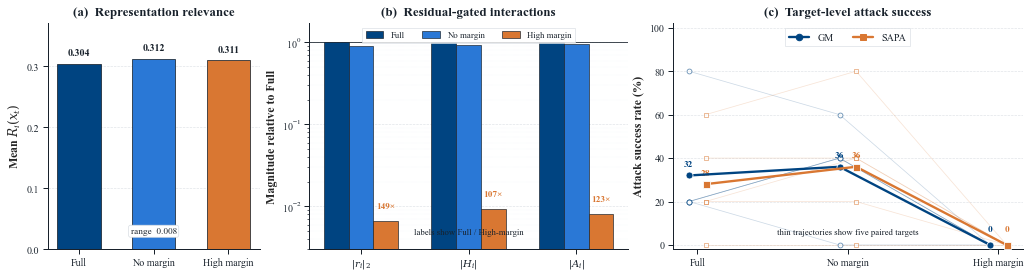

In [6]:
fig, axes = plt.subplots(
    1, 3, figsize=FIG2_SIZE,
    gridspec_kw={"width_ratios": [0.82, 1.23, 1.35]},
    constrained_layout=True,
)
x_sel = np.arange(len(SELECTOR_ORDER))
colors = [SELECTOR_COLOR[s] for s in SELECTOR_ORDER]
labels = [SELECTOR_LABEL[s] for s in SELECTOR_ORDER]

# (a) Comparable representation relevance.
ax = axes[0]
r_values = summary["selected_mean_relevance"].to_numpy(float)
bars = ax.bar(x_sel, r_values, width=0.58, color=colors, edgecolor=DARK, linewidth=0.75, zorder=3)
for bar, value in zip(bars, r_values):
    ax.text(
        bar.get_x() + bar.get_width()/2, value + 0.009, f"{value:.3f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold",
    )
ax.set_title("(a)  Representation relevance", pad=8)
ax.set_ylabel(r"Mean $R_i(x_t)$")
ax.set_xticks(x_sel, labels)
ax.set_ylim(0, 0.37)
ax.set_yticks([0.0, 0.1, 0.2, 0.3])
ax.text(
    0.5, 0.08, f"range  {r_values.max()-r_values.min():.3f}",
    transform=ax.transAxes, ha="center", va="center", fontsize=9.2,
    bbox=dict(boxstyle="round,pad=0.22", facecolor=WHITE, edgecolor=GRID, linewidth=0.7),
)
finish_axis(ax)

# (b) Suppression of both local-alignment components.
ax = axes[1]
metric_cols = [
    "selected_mean_residual_norm",
    "selected_mean_abs_head_interaction",
    "selected_mean_abs_backbone_interaction",
]
metric_labels = [r"$\|r_i\|_2$", r"$|H_i|$", r"$|A_i|$"]
raw = summary[metric_cols].to_numpy(float)
relative = raw / raw[0:1, :]
width = 0.23
for j, selector in enumerate(SELECTOR_ORDER):
    positions = np.arange(len(metric_cols)) + (j - 1) * width
    ax.bar(
        positions, relative[j], width=width,
        color=SELECTOR_COLOR[selector], edgecolor=DARK, linewidth=0.65,
        label=SELECTOR_LABEL[selector], zorder=3,
    )
high_reduction = raw[0] / raw[2]
for k, value in enumerate(high_reduction):
    y = relative[2, k]
    ax.text(
        k + width, y * 1.32, f"{value:.0f}×",
        ha="center", va="bottom", fontsize=9.2, color=ORANGE, fontweight="bold",
    )
ax.axhline(1.0, color=DARK, lw=0.8, zorder=2)
ax.set_title("(b)  Residual-gated interactions", pad=8)
ax.set_ylabel("Magnitude relative to Full")
ax.set_xticks(np.arange(len(metric_cols)), metric_labels)
ax.set_yscale("log")
ax.set_ylim(0.003, 1.7)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3,
    frameon=True, fancybox=False, edgecolor=GRID, fontsize=8.8,
)
ax.text(
    0.5, 0.055, "labels show Full / High-margin",
    transform=ax.transAxes, ha="center", va="bottom", fontsize=8.8,
)
finish_axis(ax, log_y=True)

# (c) Paired target-level ASR. Thin lines are targets and thick lines are means.
ax = axes[2]
base_x = np.arange(len(SELECTOR_ORDER), dtype=float)
offsets = {"gradmatch": -0.055, "sapa": 0.055}
mean_handles = []
for attack in ["gradmatch", "sapa"]:
    pivot = (
        selector_by_target[selector_by_target["attack"] == attack]
        .pivot(index="target_idx", columns="selector", values="asr")
        .loc[:, SELECTOR_ORDER]
        * 100.0
    )
    assert pivot.shape == (5, 3)
    x_positions = base_x + offsets[attack]
    for _, row in pivot.iterrows():
        ax.plot(
            x_positions, row.to_numpy(float),
            color=ATTACK_COLOR[attack], lw=0.75, alpha=0.20, zorder=1,
        )
        ax.scatter(
            x_positions, row.to_numpy(float), s=24,
            marker=ATTACK_MARKER[attack], facecolor=WHITE,
            edgecolor=ATTACK_COLOR[attack], linewidth=0.75, alpha=0.65, zorder=2,
        )
    means = pivot.mean(axis=0).to_numpy(float)
    ax.plot(
        x_positions, means, color=ATTACK_COLOR[attack], lw=2.35,
        marker=ATTACK_MARKER[attack], ms=7.0,
        markerfacecolor=ATTACK_COLOR[attack], markeredgecolor=WHITE,
        markeredgewidth=0.8, zorder=4,
    )
    for x_pos, value in zip(x_positions, means):
        vertical = 5.0 if value == 0 else 3.2
        ax.text(
            x_pos, value + vertical, f"{value:.0f}",
            color=ATTACK_COLOR[attack], ha="center", va="bottom",
            fontsize=9.4, fontweight="bold",
        )
    mean_handles.append(Line2D(
        [0], [0], color=ATTACK_COLOR[attack], lw=2.35,
        marker=ATTACK_MARKER[attack], ms=6.5, label=ATTACK_LABEL[attack],
    ))

ax.set_title("(c)  Target-level attack success", pad=8)
ax.set_ylabel("Attack success rate (%)")
ax.set_xticks(base_x, labels)
ax.set_ylim(-2, 102)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.legend(
    handles=mean_handles, loc="upper center", bbox_to_anchor=(0.5, 1.0),
    ncol=2, frameon=True, fancybox=False, edgecolor=GRID,
)
ax.text(
    0.5, 0.055, "thin trajectories show five paired targets",
    transform=ax.transAxes, ha="center", va="bottom", fontsize=8.8,
)
finish_axis(ax)

save_figure(fig, "residual_suppression_intervention")
plt.show()

**Suggested caption**

*Controlled intervention on the signed-margin criterion. (a) Full, No-margin,
and High-margin selection produce comparable representation relevance. (b)
Restricting selection to the highest-margin quartile reduces the residual
norm, classifier-head interaction, and backbone interaction by factors of
149, 107, and 123 relative to Full selection, despite ranking the restricted
pool by the remaining representation and backbone score. (c) Target-level ASR
over five paired targets and five victim retrainings per target. The
High-margin control yields zero ASR for both GM and SAPA, while clean test
accuracy remains between 80.38% and 80.59% across all conditions. These
results illustrate the proposition's one-way exclusion criterion and do not
show that the explicit margin penalty improves ranking outside the
residual-suppressed regime.*

## Export the exact plotted values

These machine-readable files make the figures auditable and preserve the
values used in the paper captions.

In [7]:
plot_audit = pd.DataFrame({
    "quantity": [
        "candidate_surrogate_evaluations",
        "target_surrogate_pools",
        "residual_bound_violations",
        "full_no_margin_mean_overlap_of_100",
        "residual_p90_reduction_D1_to_D9",
        "head_p90_reduction_D1_to_D9",
        "backbone_p90_reduction_D1_to_D9",
    ],
    "value": [
        checked,
        25,
        violations,
        91.6,
        p90_reduction["residual_norm"],
        p90_reduction["abs_head_interaction"],
        p90_reduction["abs_backbone_interaction"],
    ],
})
summary_export = summary.copy()
summary_export.index = [SELECTOR_LABEL[x] for x in summary_export.index]
summary_export.index.name = "selector"

plot_audit.to_csv(OUTPUT_DIR / "plot_audit.csv", index=False)
summary_export.to_csv(OUTPUT_DIR / "selector_plot_values.csv")
monotonic_audit.to_csv(OUTPUT_DIR / "monotonicity_audit_by_target_model.csv", index=False)

display(plot_audit)
display(summary_export)
print("All figure inputs and audit files exported successfully.")

,quantity,value
0,candidate_surrogate_evaluations,125000.000000
1,target_surrogate_pools,25.000000
2,residual_bound_violations,0.000000
3,full_no_margin_mean_overlap_of_100,91.600000
4,residual_p90_reduction_D1_to_D9,118046.170035
5,head_p90_reduction_D1_to_D9,92699.409525
6,backbone_p90_reduction_D1_to_D9,97349.243750


,selected_mean_margin,selected_mean_relevance,selected_mean_residual_norm,selected_mean_abs_head_interaction,selected_mean_abs_backbone_interaction,gradmatch_asr,gradmatch_cta,sapa_asr,sapa_cta
selector,,,,,,,,,
Full,5.347587,0.304226,0.029533,1.622780,18.194671,0.32,0.805864,0.28,0.805208
No margin,5.721026,0.312487,0.026810,1.520791,17.219590,0.36,0.804320,0.36,0.804876
High margin,17.110130,0.310641,0.000198,0.015179,0.147402,0.00,0.804968,0.00,0.803788


All figure inputs and audit files exported successfully.
